# Ensemble score and strategy evaluation

This notebook experiments with ensemble scores built from the XGBoost, MLP, and FT-Transformer classifier scores.

It is intentionally **load-only**:
- it does not train or tune any model;
- it loads the unified prediction file created by `11_train_dl_xgb_and_evaluate_score_strategies.ipynb`;
- it constructs ensemble scores;
- it evaluates Rank IC and portfolio rules using the same methodology as the DL/XGBoost strategy notebook.

Validation is used for score/rule selection. Test performance is reported only after a validation-selected specification is fixed.


In [1]:
# Cell 1: Imports, configuration, and paths

from __future__ import annotations

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for path in candidates:
        if (path / "outputs").exists() and (path / "scripts").exists():
            return path
    # Notebook is normally in notebooks/, so parent is repo root.
    if (start / ".." / "outputs").resolve().exists():
        return (start / "..").resolve()
    raise FileNotFoundError("Could not infer repo root. Run this notebook from the repo or notebooks/ folder.")

REPO_ROOT = find_repo_root()
PREDICTION_PATH = REPO_ROOT / "outputs/predictions/dl_xgb_predictions.parquet"

BACKTEST_DIR = REPO_ROOT / "outputs/backtests/ensemble_score_strategies"
FIGURE_DIR = BACKTEST_DIR / "figures"
BACKTEST_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Prediction file: {PREDICTION_PATH}")
print(f"Backtest output dir: {BACKTEST_DIR}")


Repo root: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164
Prediction file: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/predictions/dl_xgb_predictions.parquet
Backtest output dir: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/backtests/ensemble_score_strategies


In [2]:
# Cell 2: Load unified DL/XGBoost predictions

if not PREDICTION_PATH.exists():
    raise FileNotFoundError(
        f"{PREDICTION_PATH} not found. Run notebooks/11_train_dl_xgb_and_evaluate_score_strategies.ipynb first "
        "to create outputs/predictions/dl_xgb_predictions.parquet."
    )

df = pd.read_parquet(PREDICTION_PATH)
df["MthCalDt"] = pd.to_datetime(df["MthCalDt"])
df["split"] = df["split"].astype(str)
df = df.sort_values(["MthCalDt", "PERMNO"]).reset_index(drop=True)

required_columns = [
    "PERMNO",
    "MthCalDt",
    "split",
    "target_ret_1m",
    "target_quintile",
    "top_bottom_label",
    "prediction_xgb_classifier_score",
    "prediction_mlp_classifier_score",
    "prediction_ft_classifier_score",
]

missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

duplicate_keys = df.duplicated(["PERMNO", "MthCalDt"]).sum()
if duplicate_keys:
    raise ValueError(f"Duplicate PERMNO-MthCalDt keys found: {duplicate_keys:,}")

if df["target_ret_1m"].isna().any():
    raise ValueError("target_ret_1m contains missing values.")

display(
    df.groupby("split").agg(
        rows=("PERMNO", "size"),
        first_month=("MthCalDt", "min"),
        last_month=("MthCalDt", "max"),
        stocks=("PERMNO", "nunique"),
    )
)
print("Loaded columns:")
print("\n".join(df.columns))


,rows,first_month,last_month,stocks
split,,,,
test,868926,2015-12-31,2024-10-31,14523
train,1834902,1989-12-29,2010-11-30,19469
validation,405264,2010-12-31,2015-11-30,9129


Loaded columns:
PERMNO
gvkey
MthCalDt
split
target_ret_1m
target_quintile
top_bottom_label
prob_mlp_bottom
prob_mlp_middle
prob_mlp_top
prediction_mlp_classifier_score
prediction_mlp_score
prediction_mlp_er_train_score
prediction_mlp_regressor
prediction_mlp_reg_return
score_mlp_reg_er
score_mlp_reg_cls
prediction_xgb_regressor
prediction_xgb_classifier_score
prob_xgb_bottom
prob_xgb_middle
prob_xgb_top
prediction_ft_classifier_score
prediction_ft_er_train_score
prob_ft_bottom
prob_ft_middle
prob_ft_top


In [3]:
# Cell 3: Cross-sectional score transformations

def cross_sectional_zscore(data: pd.DataFrame, value_col: str, date_col: str = "MthCalDt") -> pd.Series:
    values = pd.to_numeric(data[value_col], errors="coerce")
    mean = values.groupby(data[date_col]).transform("mean")
    std = values.groupby(data[date_col]).transform("std")
    return ((values - mean) / std.replace(0, np.nan)).fillna(0.0)


def cross_sectional_pctrank(data: pd.DataFrame, value_col: str, date_col: str = "MthCalDt") -> pd.Series:
    values = pd.to_numeric(data[value_col], errors="coerce")
    ranks = values.groupby(data[date_col]).rank(method="average", pct=True)
    return ranks.fillna(0.5)


def monthly_rank_ic(
    data: pd.DataFrame,
    score_col: str,
    target_col: str = "target_ret_1m",
    date_col: str = "MthCalDt",
    split_col: str = "split",
) -> pd.DataFrame:
    rows = []
    for (split, month), part in data.groupby([split_col, date_col], sort=True):
        scores = pd.to_numeric(part[score_col], errors="coerce")
        target = pd.to_numeric(part[target_col], errors="coerce")
        valid = scores.notna() & target.notna()
        if valid.sum() < 5 or scores[valid].nunique() <= 1 or target[valid].nunique() <= 1:
            ic = np.nan
        else:
            ic = scores[valid].corr(target[valid], method="spearman")
        rows.append({"split": split, "month": month, "score_name": score_col, "rank_ic": ic, "n_stocks": int(valid.sum())})
    return pd.DataFrame(rows)


def summarize_rank_ic(monthly_ic: pd.DataFrame) -> pd.DataFrame:
    summary = (
        monthly_ic.dropna(subset=["rank_ic"])
        .groupby(["score_label", "split"], observed=True)["rank_ic"]
        .agg(mean_rank_ic="mean", std_rank_ic="std", months="count")
        .reset_index()
    )
    summary["rank_ic_tstat"] = summary["mean_rank_ic"] / summary["std_rank_ic"].replace(0, np.nan) * np.sqrt(summary["months"])
    return summary.sort_values(["split", "mean_rank_ic"], ascending=[True, False])


In [4]:
# Cell 4: Define base classifier scores and validation-IC weights

work = df.copy()

base_score_columns = {
    "xgb_classifier": "prediction_xgb_classifier_score",
    "mlp_classifier": "prediction_mlp_classifier_score",
    "ft_classifier": "prediction_ft_classifier_score",
}

# Add standardized and rank-transformed base scores.
for label, col in base_score_columns.items():
    work[f"z_{label}"] = cross_sectional_zscore(work, col)
    work[f"rank_{label}"] = cross_sectional_pctrank(work, col)

# Compute validation Rank IC for base scores only. These are used only for validation-weighted ensemble weights.
base_ic_frames = []
for label, col in base_score_columns.items():
    tmp = monthly_rank_ic(work, col)
    tmp["score_label"] = label
    base_ic_frames.append(tmp)

base_monthly_ic = pd.concat(base_ic_frames, ignore_index=True)
base_rank_ic_summary = summarize_rank_ic(base_monthly_ic)

base_validation_ic = (
    base_rank_ic_summary.loc[base_rank_ic_summary["split"].eq("validation")]
    .set_index("score_label")["mean_rank_ic"]
    .reindex(base_score_columns.keys())
)

positive_ic = base_validation_ic.clip(lower=0)
if positive_ic.sum() <= 0:
    valic_weights = pd.Series(1.0 / len(base_score_columns), index=base_score_columns.keys())
else:
    valic_weights = positive_ic / positive_ic.sum()

ensemble_weights = valic_weights.rename("validation_ic_weight").reset_index().rename(columns={"index": "score_label"})
ensemble_weights["validation_mean_rank_ic"] = ensemble_weights["score_label"].map(base_validation_ic)

ensemble_weights.to_csv(BACKTEST_DIR / "ensemble_validation_ic_weights.csv", index=False)
display(ensemble_weights)


,score_label,validation_ic_weight,validation_mean_rank_ic
0,xgb_classifier,0.309074,0.074777
1,mlp_classifier,0.304061,0.073564
2,ft_classifier,0.386866,0.093598


In [5]:
# Cell 5: Build candidate ensemble scores

score_columns = {}

# Keep base classifier scores as benchmarks.
for label, col in base_score_columns.items():
    score_columns[label] = col

# Equal-weight z-score ensemble of all three classifiers.
work["ens_cls_equal_z"] = (
    work["z_xgb_classifier"] + work["z_mlp_classifier"] + work["z_ft_classifier"]
) / 3.0
score_columns["ens_cls_equal_z"] = "ens_cls_equal_z"

# Rank-average ensemble of all three classifiers.
work["ens_cls_rank_avg"] = (
    work["rank_xgb_classifier"] + work["rank_mlp_classifier"] + work["rank_ft_classifier"]
) / 3.0
score_columns["ens_cls_rank_avg"] = "ens_cls_rank_avg"

# Pairwise equal-z ensembles.
work["ens_ft_mlp_equal_z"] = (work["z_ft_classifier"] + work["z_mlp_classifier"]) / 2.0
work["ens_ft_xgb_equal_z"] = (work["z_ft_classifier"] + work["z_xgb_classifier"]) / 2.0
work["ens_mlp_xgb_equal_z"] = (work["z_mlp_classifier"] + work["z_xgb_classifier"]) / 2.0

score_columns["ens_ft_mlp_equal_z"] = "ens_ft_mlp_equal_z"
score_columns["ens_ft_xgb_equal_z"] = "ens_ft_xgb_equal_z"
score_columns["ens_mlp_xgb_equal_z"] = "ens_mlp_xgb_equal_z"

# Validation-Rank-IC-weighted ensemble using validation only.
work["ens_cls_valic_weighted_z"] = 0.0
for label, weight in valic_weights.items():
    work["ens_cls_valic_weighted_z"] += float(weight) * work[f"z_{label}"]
score_columns["ens_cls_valic_weighted_z"] = "ens_cls_valic_weighted_z"

# Optional: use ER-train scores as benchmarks if present, but not in main ensembles.
optional_benchmarks = {
    "xgb_er_train": ["score_xgb_er_train", "prediction_xgb_er_train_score"],
    "mlp_er_train": ["score_mlp_er_train", "prediction_mlp_er_train_score"],
    "ft_er_train": ["score_ft_er_train", "prediction_ft_er_train_score"],
}
for label, candidates in optional_benchmarks.items():
    for candidate in candidates:
        if candidate in work.columns:
            score_columns[label] = candidate
            break

print("Candidate scores:")
for label, col in score_columns.items():
    print(f"{label:30s} -> {col}")


Candidate scores:
xgb_classifier                 -> prediction_xgb_classifier_score
mlp_classifier                 -> prediction_mlp_classifier_score
ft_classifier                  -> prediction_ft_classifier_score
ens_cls_equal_z                -> ens_cls_equal_z
ens_cls_rank_avg               -> ens_cls_rank_avg
ens_ft_mlp_equal_z             -> ens_ft_mlp_equal_z
ens_ft_xgb_equal_z             -> ens_ft_xgb_equal_z
ens_mlp_xgb_equal_z            -> ens_mlp_xgb_equal_z
ens_cls_valic_weighted_z       -> ens_cls_valic_weighted_z
mlp_er_train                   -> prediction_mlp_er_train_score
ft_er_train                    -> prediction_ft_er_train_score


In [6]:
# Cell 6: Monthly Rank IC for base and ensemble scores

monthly_ic_frames = []
for label, col in score_columns.items():
    tmp = monthly_rank_ic(work, col)
    tmp["score_label"] = label
    monthly_ic_frames.append(tmp)

monthly_ic_all = pd.concat(monthly_ic_frames, ignore_index=True)
rank_ic_summary = summarize_rank_ic(monthly_ic_all)

monthly_ic_all.to_csv(BACKTEST_DIR / "ensemble_score_monthly_rank_ic.csv", index=False)
rank_ic_summary.to_csv(BACKTEST_DIR / "ensemble_score_rank_ic_summary.csv", index=False)

validation_rank_ic = (
    rank_ic_summary.loc[rank_ic_summary["split"].eq("validation")]
    .sort_values("mean_rank_ic", ascending=False)
    .reset_index(drop=True)
)

display(validation_rank_ic)


,score_label,split,mean_rank_ic,std_rank_ic,months,rank_ic_tstat
0,ft_classifier,validation,0.093598,0.121390,60,5.972553
1,ens_cls_valic_weighted_z,validation,0.089078,0.102963,60,6.701363
2,ens_cls_rank_avg,validation,0.088624,0.103491,60,6.633213
3,ens_ft_mlp_equal_z,validation,0.088408,0.099057,60,6.913235
4,ens_cls_equal_z,validation,0.088104,0.101378,60,6.731754
5,ens_ft_xgb_equal_z,validation,0.087973,0.109200,60,6.240269
6,ft_er_train,validation,0.086685,0.103365,60,6.496029
7,ens_mlp_xgb_equal_z,validation,0.080958,0.095382,60,6.574639
8,xgb_classifier,validation,0.074777,0.096928,60,5.975759
9,mlp_classifier,validation,0.073564,0.089834,60,6.343087


In [7]:
# Cell 7: Portfolio construction helpers

def make_weights_for_month(
    part: pd.DataFrame,
    score_col: str,
    rule: str,
    q: float = 0.20,
    short_exposure: float = 1.0,
    long_exposure: float = 1.0,
    sign_gate: bool = False,
    threshold_gate: bool = False,
    zero_threshold: float = 0.0,
) -> pd.Series:
    if sign_gate and threshold_gate:
        raise ValueError("Use either sign_gate or threshold_gate, not both.")

    scores = pd.to_numeric(part[score_col], errors="coerce")
    valid = scores.notna()
    weights = pd.Series(0.0, index=part.index)

    if valid.sum() < 10:
        return weights

    ranks = scores[valid].rank(method="first", pct=True)
    long_idx = ranks[ranks >= 1 - q].index
    short_idx = ranks[ranks <= q].index

    if sign_gate:
        long_idx = long_idx[scores.loc[long_idx] > 0]
        short_idx = short_idx[scores.loc[short_idx] < 0]
    elif threshold_gate:
        long_idx = long_idx[scores.loc[long_idx] > zero_threshold]
        short_idx = short_idx[scores.loc[short_idx] < -zero_threshold]

    if rule == "long_only":
        if len(long_idx) > 0:
            weights.loc[long_idx] = 1.0 / len(long_idx)
        return weights

    if rule == "long_short":
        le = long_exposure
        se = short_exposure
    elif rule == "gross_normalized_long_short":
        le = 0.5
        se = 0.5
    elif rule == "long_short_130_30":
        le = 1.3
        se = 0.3
    else:
        raise ValueError(f"Unknown rule: {rule}")

    if len(long_idx) > 0:
        weights.loc[long_idx] = le / len(long_idx)
    if len(short_idx) > 0:
        weights.loc[short_idx] = -se / len(short_idx)

    return weights


def build_portfolio_returns(
    data: pd.DataFrame,
    score_label: str,
    score_col: str,
    rule: str,
    q: float = 0.20,
    sign_gate: bool = False,
    threshold_gate: bool = False,
    zero_threshold: float = 0.0,
    one_way_cost_bps: float = 0.0,
    target_col: str = "target_ret_1m",
    date_col: str = "MthCalDt",
    split_col: str = "split",
) -> pd.DataFrame:
    rows = []
    previous_weights = None
    data = data.sort_values([date_col, "PERMNO"]).copy()

    for (split, month), part in data.groupby([split_col, date_col], sort=True):
        weights = make_weights_for_month(
            part,
            score_col=score_col,
            rule=rule,
            q=q,
            sign_gate=sign_gate,
            threshold_gate=threshold_gate,
            zero_threshold=zero_threshold,
        )

        returns = pd.to_numeric(part[target_col], errors="coerce").fillna(0.0)
        gross_return = float((weights * returns).sum())

        long_weight = weights.clip(lower=0).sum()
        short_weight = -weights.clip(upper=0).sum()
        gross_exposure = weights.abs().sum()
        net_exposure = weights.sum()

        long_return = np.nan
        short_leg_return = np.nan
        short_leg_contribution = np.nan

        if long_weight > 0:
            long_return = float((weights.clip(lower=0) * returns).sum() / long_weight)
        if short_weight > 0:
            short_leg_contribution = float((weights.clip(upper=0) * returns).sum())
            short_leg_return = float(short_leg_contribution / short_weight)

        current_weights = pd.Series(weights.values, index=part["PERMNO"].values)
        if previous_weights is None:
            turnover = float(current_weights.abs().sum())
        else:
            aligned = pd.concat([previous_weights.rename("prev"), current_weights.rename("curr")], axis=1).fillna(0.0)
            turnover = float((aligned["curr"] - aligned["prev"]).abs().sum())

        cost = (one_way_cost_bps / 10_000.0) * turnover
        net_return = gross_return - cost

        rows.append(
            {
                "split": split,
                "month": month,
                "score_label": score_label,
                "score_col": score_col,
                "rule": rule,
                "q": q,
                "sign_gate": sign_gate,
                "threshold_gate": threshold_gate,
                "zero_threshold": zero_threshold,
                "one_way_cost_bps": one_way_cost_bps,
                "gross_return": gross_return,
                "turnover": turnover,
                "trading_cost": cost,
                "net_return": net_return,
                "long_weight": float(long_weight),
                "short_weight": float(short_weight),
                "gross_exposure": float(gross_exposure),
                "net_exposure": float(net_exposure),
                "long_leg_return": long_return,
                "short_leg_return": short_leg_return,
                "short_leg_contribution": short_leg_contribution,
                "n_long": int((weights > 0).sum()),
                "n_short": int((weights < 0).sum()),
            }
        )

        previous_weights = current_weights

    return pd.DataFrame(rows)


In [8]:
# Cell 8: Portfolio performance summary helpers

def max_drawdown(returns: pd.Series) -> float:
    wealth = (1.0 + returns.fillna(0.0)).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1.0
    return float(drawdown.min())


def annualized_return(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if len(monthly_returns) == 0:
        return np.nan
    total = (1.0 + monthly_returns).prod()
    years = len(monthly_returns) / 12.0
    return float(total ** (1.0 / years) - 1.0)


def annualized_volatility(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if len(monthly_returns) <= 1:
        return np.nan
    return float(monthly_returns.std() * np.sqrt(12))


def sharpe_ratio(monthly_returns: pd.Series) -> float:
    ann_ret = annualized_return(monthly_returns)
    ann_vol = annualized_volatility(monthly_returns)
    if ann_vol == 0 or pd.isna(ann_vol):
        return np.nan
    return float(ann_ret / ann_vol)


def summarize_portfolios(monthly: pd.DataFrame, return_col: str = "net_return") -> pd.DataFrame:
    rows = []
    group_cols = ["score_label", "rule", "q", "sign_gate", "threshold_gate", "zero_threshold", "one_way_cost_bps", "split"]

    for keys, part in monthly.groupby(group_cols, observed=True):
        score_label, rule, q, sign_gate, threshold_gate, zero_threshold, cost_bps, split = keys
        rets = part[return_col]
        rows.append(
            {
                "score_label": score_label,
                "rule": rule,
                "q": q,
                "sign_gate": sign_gate,
                "threshold_gate": threshold_gate,
                "zero_threshold": zero_threshold,
                "one_way_cost_bps": cost_bps,
                "split": split,
                "months": len(part),
                "annualized_return": annualized_return(rets),
                "annualized_volatility": annualized_volatility(rets),
                "sharpe": sharpe_ratio(rets),
                "max_drawdown": max_drawdown(rets),
                "mean_monthly_return": rets.mean(),
                "std_monthly_return": rets.std(),
                "average_turnover": part["turnover"].mean(),
                "average_gross_exposure": part["gross_exposure"].mean(),
                "average_net_exposure": part["net_exposure"].mean(),
                "average_long_weight": part["long_weight"].mean(),
                "average_short_weight": part["short_weight"].mean(),
                "average_n_long": part["n_long"].mean(),
                "average_n_short": part["n_short"].mean(),
                "average_long_leg_return": part["long_leg_return"].mean(),
                "average_short_leg_return": part["short_leg_return"].mean(),
                "average_short_leg_contribution": part["short_leg_contribution"].mean(),
            }
        )

    return pd.DataFrame(rows)


In [9]:
# Cell 9: Strategy grid

# Same limited rule grid as the DL/XGBoost notebook.
THRESHOLD_GRID = [0.00, 0.01, 0.02]

strategy_grid = [
    {"rule": "long_only", "q": 0.20, "sign_gate": False, "threshold_gate": False, "zero_threshold": 0.0},
    {"rule": "gross_normalized_long_short", "q": 0.20, "sign_gate": False, "threshold_gate": False, "zero_threshold": 0.0},
    {"rule": "long_short_130_30", "q": 0.20, "sign_gate": False, "threshold_gate": False, "zero_threshold": 0.0},
]
for tau in THRESHOLD_GRID:
    strategy_grid.append({"rule": "long_short", "q": 0.20, "sign_gate": False, "threshold_gate": True, "zero_threshold": tau})

cost_grid_bps = [0.0, 10.0, 25.0]

# Main ensemble scores plus base classifier benchmarks.
candidate_score_labels = [
    "xgb_classifier",
    "mlp_classifier",
    "ft_classifier",
    "ens_cls_equal_z",
    "ens_cls_rank_avg",
    "ens_ft_mlp_equal_z",
    "ens_ft_xgb_equal_z",
    "ens_mlp_xgb_equal_z",
    "ens_cls_valic_weighted_z",
]

candidate_score_labels = [label for label in candidate_score_labels if label in score_columns]

print("Candidate score labels used in the strategy grid:")
for label in candidate_score_labels:
    print(label)


Candidate score labels used in the strategy grid:
xgb_classifier
mlp_classifier
ft_classifier
ens_cls_equal_z
ens_cls_rank_avg
ens_ft_mlp_equal_z
ens_ft_xgb_equal_z
ens_mlp_xgb_equal_z
ens_cls_valic_weighted_z


In [10]:
# Cell 10: Run validation/test backtests

portfolio_frames = []
work_small = work.loc[work["split"].isin(["validation", "test"])].copy()

for score_label in candidate_score_labels:
    score_col = score_columns[score_label]
    for strategy in strategy_grid:
        # Weights do not depend on transaction cost, so compute once at 0 bps and re-price costs.
        bt_base = build_portfolio_returns(
            work_small,
            score_label=score_label,
            score_col=score_col,
            rule=strategy["rule"],
            q=strategy["q"],
            sign_gate=strategy["sign_gate"],
            threshold_gate=strategy["threshold_gate"],
            zero_threshold=strategy["zero_threshold"],
            one_way_cost_bps=0.0,
        )

        for cost_bps in cost_grid_bps:
            bt = bt_base.copy()
            bt["one_way_cost_bps"] = cost_bps
            bt["trading_cost"] = (cost_bps / 10_000.0) * bt["turnover"]
            bt["net_return"] = bt["gross_return"] - bt["trading_cost"]
            portfolio_frames.append(bt)

portfolio_monthly = pd.concat(portfolio_frames, ignore_index=True)

portfolio_summary_net = summarize_portfolios(portfolio_monthly, return_col="net_return")
portfolio_summary_gross = summarize_portfolios(portfolio_monthly, return_col="gross_return").rename(
    columns={
        "annualized_return": "gross_annualized_return",
        "annualized_volatility": "gross_annualized_volatility",
        "sharpe": "gross_sharpe",
        "max_drawdown": "gross_max_drawdown",
        "mean_monthly_return": "gross_mean_monthly_return",
        "std_monthly_return": "gross_std_monthly_return",
    }
)

merge_cols = ["score_label", "rule", "q", "sign_gate", "threshold_gate", "zero_threshold", "one_way_cost_bps", "split"]
portfolio_summary = portfolio_summary_net.merge(
    portfolio_summary_gross[
        merge_cols
        + [
            "gross_annualized_return",
            "gross_annualized_volatility",
            "gross_sharpe",
            "gross_max_drawdown",
            "gross_mean_monthly_return",
            "gross_std_monthly_return",
        ]
    ],
    on=merge_cols,
    how="left",
)

portfolio_monthly.to_csv(BACKTEST_DIR / "ensemble_score_strategy_monthly_returns.csv", index=False)
portfolio_summary.to_csv(BACKTEST_DIR / "ensemble_score_strategy_performance_summary.csv", index=False)

display(portfolio_summary.head())


,score_label,rule,q,sign_gate,threshold_gate,zero_threshold,one_way_cost_bps,split,months,annualized_return,annualized_volatility,sharpe,max_drawdown,mean_monthly_return,std_monthly_return,average_turnover,average_gross_exposure,average_net_exposure,average_long_weight,average_short_weight,average_n_long,average_n_short,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,gross_annualized_return,gross_annualized_volatility,gross_sharpe,gross_max_drawdown,gross_mean_monthly_return,gross_std_monthly_return
0,ens_cls_equal_z,gross_normalized_long_short,0.2,False,False,0.0,0.0,test,107,0.056911,0.113035,0.503484,-0.338763,0.005159,0.032630,0.439907,1.0,2.584860e-18,0.5,0.5,1624.757009,1623.757009,0.01099,-0.000671,-0.000336,0.056911,0.113035,0.503484,-0.338763,0.005159,0.032630
1,ens_cls_equal_z,gross_normalized_long_short,0.2,False,False,0.0,0.0,validation,60,0.065602,0.061606,1.064863,-0.071084,0.005465,0.017784,0.457304,1.0,-1.734723e-18,0.5,0.5,1351.516667,1350.516667,0.00932,0.001610,0.000805,0.065602,0.061606,1.064863,-0.071084,0.005465,0.017784
2,ens_cls_equal_z,gross_normalized_long_short,0.2,False,False,0.0,10.0,test,107,0.051356,0.113132,0.453951,-0.345145,0.004719,0.032658,0.439907,1.0,2.584860e-18,0.5,0.5,1624.757009,1623.757009,0.01099,-0.000671,-0.000336,0.056911,0.113035,0.503484,-0.338763,0.005159,0.032630
3,ens_cls_equal_z,gross_normalized_long_short,0.2,False,False,0.0,10.0,validation,60,0.059797,0.061632,0.970233,-0.074204,0.005007,0.017792,0.457304,1.0,-1.734723e-18,0.5,0.5,1351.516667,1350.516667,0.00932,0.001610,0.000805,0.065602,0.061606,1.064863,-0.071084,0.005465,0.017784
4,ens_cls_equal_z,gross_normalized_long_short,0.2,False,False,0.0,25.0,test,107,0.043073,0.113282,0.380230,-0.354609,0.004060,0.032702,0.439907,1.0,2.584860e-18,0.5,0.5,1624.757009,1623.757009,0.01099,-0.000671,-0.000336,0.056911,0.113035,0.503484,-0.338763,0.005159,0.032630


## Validation-only selection

The table below ranks score/rule combinations on the validation split. The test split must not be used to choose the ensemble score, cost assumption, threshold, or portfolio rule.


In [11]:
# Cell 11: Build validation selection table

VALIDATION_RANKING_COLUMNS = [
    "score_label",
    "rule",
    "q",
    "threshold_gate",
    "zero_threshold",
    "one_way_cost_bps",
    "validation_composite_score",
    "validation_rank_ic",
    "validation_rank_ic_tstat",
    "validation_net_sharpe",
    "validation_net_annualized_return",
    "validation_net_annualized_volatility",
    "average_turnover",
    "average_gross_exposure",
    "average_n_long",
    "average_n_short",
    "max_drawdown",
    "eligible_for_selection",
]


def build_validation_selection_ranking(portfolio_summary: pd.DataFrame, validation_rank_ic: pd.DataFrame) -> pd.DataFrame:
    rank_ic_lookup = validation_rank_ic[["score_label", "mean_rank_ic", "rank_ic_tstat"]].rename(
        columns={
            "mean_rank_ic": "validation_rank_ic",
            "rank_ic_tstat": "validation_rank_ic_tstat",
        }
    )

    ranking = (
        portfolio_summary.loc[portfolio_summary["split"].eq("validation")]
        .merge(rank_ic_lookup, on="score_label", how="left", validate="many_to_one")
        .copy()
    )

    ranking["validation_net_sharpe"] = ranking["sharpe"]
    ranking["validation_net_annualized_return"] = ranking["annualized_return"]
    ranking["validation_net_annualized_volatility"] = ranking["annualized_volatility"]

    ranking["eligible_for_selection"] = (
        ranking["validation_rank_ic"].notna()
        & ranking["validation_net_sharpe"].notna()
        & ranking["validation_net_annualized_return"].notna()
        & ranking["validation_net_annualized_volatility"].notna()
        & ranking["average_turnover"].notna()
        & ranking["average_turnover"].gt(0)
        & ranking["average_gross_exposure"].gt(0)
        & ranking["validation_net_annualized_volatility"].gt(0)
    )

    # Balanced validation criterion: ranking quality + economic performance - costs/risk/turnover.
    # max_drawdown is negative, so adding it penalizes deeper drawdowns.
    ranking["validation_composite_score"] = (
        ranking["validation_rank_ic"]
        + ranking["validation_net_sharpe"]
        + ranking["validation_net_annualized_return"]
        + ranking["max_drawdown"]
        - ranking["average_turnover"]
        - ranking["validation_net_annualized_volatility"]
    )
    ranking.loc[~ranking["eligible_for_selection"], "validation_composite_score"] = -np.inf

    return ranking.sort_values(
        ["one_way_cost_bps", "eligible_for_selection", "validation_composite_score", "validation_net_sharpe", "validation_net_annualized_return"],
        ascending=[True, False, False, False, False],
    ).reset_index(drop=True)


validation_portfolios = build_validation_selection_ranking(portfolio_summary, validation_rank_ic)
validation_portfolios.to_csv(BACKTEST_DIR / "ensemble_validation_strategy_ranking.csv", index=False)

for cost in cost_grid_bps:
    print(f"Validation ranking by composite score at {cost:.0f} bps")
    ranking = validation_portfolios.loc[validation_portfolios["one_way_cost_bps"].eq(cost)].reset_index(drop=True)
    display(ranking[VALIDATION_RANKING_COLUMNS].head(25))


Validation ranking by composite score at 0 bps


,score_label,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,average_gross_exposure,average_n_long,average_n_short,max_drawdown,eligible_for_selection
0,ft_classifier,long_short_130_30,0.2,False,0.00,0.0,0.728514,0.093598,5.972553,1.424194,0.161942,0.113708,0.718882,1.6,1351.516667,1350.516667,-0.118630,True
1,ens_ft_mlp_equal_z,gross_normalized_long_short,0.2,False,0.00,0.0,0.640483,0.088408,6.913235,1.063835,0.064861,0.060969,0.435716,1.0,1351.516667,1350.516667,-0.079936,True
2,ens_cls_equal_z,gross_normalized_long_short,0.2,False,0.00,0.0,0.628575,0.088104,6.731754,1.064863,0.065602,0.061606,0.457304,1.0,1351.516667,1350.516667,-0.071084,True
3,ens_cls_valic_weighted_z,gross_normalized_long_short,0.2,False,0.00,0.0,0.618994,0.089078,6.701363,1.049098,0.065586,0.062517,0.448889,1.0,1351.516667,1350.516667,-0.073362,True
4,ens_mlp_xgb_equal_z,gross_normalized_long_short,0.2,False,0.00,0.0,0.603177,0.080958,6.574639,1.094004,0.064244,0.058724,0.515840,1.0,1351.516667,1350.516667,-0.061466,True
5,ft_classifier,gross_normalized_long_short,0.2,False,0.00,0.0,0.542449,0.093598,5.972553,0.934049,0.066235,0.070912,0.390858,1.0,1351.516667,1350.516667,-0.089663,True
6,ens_ft_xgb_equal_z,gross_normalized_long_short,0.2,False,0.00,0.0,0.533508,0.087973,6.240269,0.996680,0.064081,0.064294,0.485355,1.0,1351.516667,1350.516667,-0.065578,True
7,xgb_classifier,gross_normalized_long_short,0.2,False,0.00,0.0,0.526884,0.074777,5.975759,1.084272,0.062031,0.057210,0.578341,1.0,1351.516667,1350.516667,-0.058645,True
8,ens_cls_rank_avg,gross_normalized_long_short,0.2,False,0.00,0.0,0.510228,0.088624,6.633213,0.972240,0.060968,0.062709,0.468028,1.0,1351.516667,1350.516667,-0.080867,True
9,ft_classifier,long_only,0.2,False,0.00,0.0,0.435204,0.093598,5.972553,0.998537,0.116428,0.116599,0.484368,1.0,1351.516667,0.000000,-0.172392,True


Validation ranking by composite score at 10 bps


,score_label,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,average_gross_exposure,average_n_long,average_n_short,max_drawdown,eligible_for_selection
0,ft_classifier,long_short_130_30,0.2,False,0.00,10.0,0.627206,0.093598,5.972553,1.335990,0.152062,0.113820,0.718882,1.6,1351.516667,1350.516667,-0.121742,True
1,ens_ft_mlp_equal_z,gross_normalized_long_short,0.2,False,0.00,10.0,0.540578,0.088408,6.913235,0.972367,0.059332,0.061018,0.435716,1.0,1351.516667,1350.516667,-0.082794,True
2,ens_cls_equal_z,gross_normalized_long_short,0.2,False,0.00,10.0,0.524994,0.088104,6.731754,0.970233,0.059797,0.061632,0.457304,1.0,1351.516667,1350.516667,-0.074204,True
3,ens_cls_valic_weighted_z,gross_normalized_long_short,0.2,False,0.00,10.0,0.518659,0.089078,6.701363,0.957540,0.059888,0.062543,0.448889,1.0,1351.516667,1350.516667,-0.076414,True
4,ens_mlp_xgb_equal_z,gross_normalized_long_short,0.2,False,0.00,10.0,0.481611,0.080958,6.574639,0.982541,0.057708,0.058733,0.515840,1.0,1351.516667,1350.516667,-0.065023,True
5,ft_classifier,gross_normalized_long_short,0.2,False,0.00,10.0,0.458055,0.093598,5.972553,0.863369,0.061267,0.070962,0.390858,1.0,1351.516667,1350.516667,-0.098359,True
6,ens_ft_xgb_equal_z,gross_normalized_long_short,0.2,False,0.00,10.0,0.426957,0.087973,6.240269,0.900021,0.057926,0.064360,0.485355,1.0,1351.516667,1350.516667,-0.069248,True
7,ens_cls_rank_avg,gross_normalized_long_short,0.2,False,0.00,10.0,0.403545,0.088624,6.633213,0.876987,0.055049,0.062770,0.468028,1.0,1351.516667,1350.516667,-0.086317,True
8,xgb_classifier,gross_normalized_long_short,0.2,False,0.00,10.0,0.389504,0.074777,5.975759,0.955802,0.054717,0.057248,0.578341,1.0,1351.516667,1350.516667,-0.060203,True
9,ft_classifier,long_only,0.2,False,0.00,10.0,0.371113,0.093598,5.972553,0.942915,0.110004,0.116663,0.484368,1.0,1351.516667,0.000000,-0.174372,True


Validation ranking by composite score at 25 bps


,score_label,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,average_gross_exposure,average_n_long,average_n_short,max_drawdown,eligible_for_selection
0,ft_classifier,long_short_130_30,0.2,False,0.00,25.0,0.476760,0.093598,5.972553,1.205060,0.137384,0.114006,0.718882,1.6,1351.516667,1350.516667,-0.126394,True
1,ens_ft_mlp_equal_z,gross_normalized_long_short,0.2,False,0.00,25.0,0.389699,0.088408,6.913235,0.836019,0.051086,0.061106,0.435716,1.0,1351.516667,1350.516667,-0.088992,True
2,ens_cls_equal_z,gross_normalized_long_short,0.2,False,0.00,25.0,0.370489,0.088104,6.731754,0.829098,0.051144,0.061686,0.457304,1.0,1351.516667,1350.516667,-0.078866,True
3,ens_cls_valic_weighted_z,gross_normalized_long_short,0.2,False,0.00,25.0,0.368989,0.089078,6.701363,0.820980,0.051391,0.062598,0.448889,1.0,1351.516667,1350.516667,-0.080974,True
4,ft_classifier,gross_normalized_long_short,0.2,False,0.00,25.0,0.332255,0.093598,5.972553,0.757963,0.053853,0.071049,0.390858,1.0,1351.516667,1350.516667,-0.111252,True
5,ens_mlp_xgb_equal_z,gross_normalized_long_short,0.2,False,0.00,25.0,0.300300,0.080958,6.574639,0.816311,0.047971,0.058765,0.515840,1.0,1351.516667,1350.516667,-0.070335,True
6,ft_classifier,long_only,0.2,False,0.00,25.0,0.275636,0.093598,5.972553,0.860078,0.100429,0.116767,0.484368,1.0,1351.516667,0.000000,-0.177334,True
7,ens_ft_xgb_equal_z,gross_normalized_long_short,0.2,False,0.00,25.0,0.261927,0.087973,6.240269,0.756187,0.048754,0.064473,0.485355,1.0,1351.516667,1350.516667,-0.081159,True
8,ens_cls_rank_avg,gross_normalized_long_short,0.2,False,0.00,25.0,0.236384,0.088624,6.633213,0.735172,0.046226,0.062877,0.468028,1.0,1351.516667,1350.516667,-0.102733,True
9,xgb_classifier,gross_normalized_long_short,0.2,False,0.00,25.0,0.185097,0.074777,5.975759,0.764686,0.043832,0.057320,0.578341,1.0,1351.516667,1350.516667,-0.062537,True


In [12]:
# Cell 12: Fixed-rule comparison at 10 bps

FIXED_RULE = "gross_normalized_long_short"
FIXED_COST_BPS = 10.0

fixed_rule_scores = [
    "xgb_classifier",
    "mlp_classifier",
    "ft_classifier",
    "ens_cls_equal_z",
    "ens_cls_rank_avg",
    "ens_ft_mlp_equal_z",
    "ens_ft_xgb_equal_z",
    "ens_cls_valic_weighted_z",
]
fixed_rule_scores = [s for s in fixed_rule_scores if s in score_columns]

fixed_rule_table = portfolio_summary.loc[
    portfolio_summary["score_label"].isin(fixed_rule_scores)
    & portfolio_summary["rule"].eq(FIXED_RULE)
    & portfolio_summary["one_way_cost_bps"].eq(FIXED_COST_BPS)
    & portfolio_summary["threshold_gate"].eq(False)
].merge(
    rank_ic_summary[["score_label", "split", "mean_rank_ic", "rank_ic_tstat"]],
    on=["score_label", "split"],
    how="left",
)

fixed_rule_table = fixed_rule_table.sort_values(["split", "sharpe"], ascending=[True, False])
fixed_rule_table.to_csv(BACKTEST_DIR / "ensemble_fixed_rule_model_comparison.csv", index=False)

display(
    fixed_rule_table[
        [
            "split",
            "score_label",
            "mean_rank_ic",
            "rank_ic_tstat",
            "annualized_return",
            "annualized_volatility",
            "sharpe",
            "max_drawdown",
            "average_turnover",
            "average_gross_exposure",
        ]
    ]
)


,split,score_label,mean_rank_ic,rank_ic_tstat,annualized_return,annualized_volatility,sharpe,max_drawdown,average_turnover,average_gross_exposure
14,test,xgb_classifier,0.079483,6.397950,0.056426,0.100674,0.560484,-0.273870,0.598303,1.0
12,test,mlp_classifier,0.095714,7.734406,0.052069,0.103039,0.505326,-0.303877,0.504697,1.0
0,test,ens_cls_equal_z,0.094354,6.612306,0.051356,0.113132,0.453951,-0.345145,0.439907,1.0
4,test,ens_cls_valic_weighted_z,0.094464,6.560155,0.050475,0.114061,0.442525,-0.349066,0.430555,1.0
2,test,ens_cls_rank_avg,0.094393,6.573225,0.049436,0.111996,0.441413,-0.351656,0.443359,1.0
6,test,ens_ft_mlp_equal_z,0.097974,7.005589,0.044636,0.111656,0.399760,-0.359546,0.412201,1.0
8,test,ens_ft_xgb_equal_z,0.089907,6.195266,0.044438,0.116923,0.380061,-0.357678,0.472977,1.0
10,test,ft_classifier,0.093301,6.190526,0.033077,0.118803,0.278415,-0.396870,0.403408,1.0
7,validation,ens_ft_mlp_equal_z,0.088408,6.913235,0.059332,0.061018,0.972367,-0.082794,0.435716,1.0
1,validation,ens_cls_equal_z,0.088104,6.731754,0.059797,0.061632,0.970233,-0.074204,0.457304,1.0


In [13]:
# Cell 13: Choose validation spec and report matching test performance

SELECTION_COST_BPS = 10.0
SELECTION_SORT = ["validation_composite_score", "validation_net_sharpe", "validation_net_annualized_return"]

selection_table = (
    validation_portfolios.loc[
        validation_portfolios["one_way_cost_bps"].eq(SELECTION_COST_BPS)
        & validation_portfolios["eligible_for_selection"]
    ]
    .sort_values(SELECTION_SORT, ascending=[False, False, False])
    .reset_index(drop=True)
)

if selection_table.empty:
    raise ValueError("No eligible validation strategies found.")

display(selection_table[VALIDATION_RANKING_COLUMNS].head(30))

SPEC_COLUMNS = ["score_label", "rule", "q", "sign_gate", "threshold_gate", "zero_threshold", "one_way_cost_bps"]

top_validation_specs = selection_table.head(10)[SPEC_COLUMNS].copy()
chosen_spec = top_validation_specs.iloc[0].to_dict()

test_selected_specs = top_validation_specs.merge(
    portfolio_summary.loc[portfolio_summary["split"].eq("test")],
    on=SPEC_COLUMNS,
    how="left",
)

test_selected_specs.to_csv(BACKTEST_DIR / "ensemble_test_performance_of_top_validation_specs.csv", index=False)

print("Chosen validation specification:")
print(chosen_spec)

display(
    test_selected_specs[
        SPEC_COLUMNS
        + [
            "annualized_return",
            "annualized_volatility",
            "sharpe",
            "max_drawdown",
            "average_turnover",
            "average_gross_exposure",
            "average_n_long",
            "average_n_short",
        ]
    ]
)


,score_label,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,average_gross_exposure,average_n_long,average_n_short,max_drawdown,eligible_for_selection
0,ft_classifier,long_short_130_30,0.2,False,0.00,10.0,0.627206,0.093598,5.972553,1.335990,0.152062,0.113820,0.718882,1.6,1351.516667,1350.516667,-0.121742,True
1,ens_ft_mlp_equal_z,gross_normalized_long_short,0.2,False,0.00,10.0,0.540578,0.088408,6.913235,0.972367,0.059332,0.061018,0.435716,1.0,1351.516667,1350.516667,-0.082794,True
2,ens_cls_equal_z,gross_normalized_long_short,0.2,False,0.00,10.0,0.524994,0.088104,6.731754,0.970233,0.059797,0.061632,0.457304,1.0,1351.516667,1350.516667,-0.074204,True
3,ens_cls_valic_weighted_z,gross_normalized_long_short,0.2,False,0.00,10.0,0.518659,0.089078,6.701363,0.957540,0.059888,0.062543,0.448889,1.0,1351.516667,1350.516667,-0.076414,True
4,ens_mlp_xgb_equal_z,gross_normalized_long_short,0.2,False,0.00,10.0,0.481611,0.080958,6.574639,0.982541,0.057708,0.058733,0.515840,1.0,1351.516667,1350.516667,-0.065023,True
5,ft_classifier,gross_normalized_long_short,0.2,False,0.00,10.0,0.458055,0.093598,5.972553,0.863369,0.061267,0.070962,0.390858,1.0,1351.516667,1350.516667,-0.098359,True
6,ens_ft_xgb_equal_z,gross_normalized_long_short,0.2,False,0.00,10.0,0.426957,0.087973,6.240269,0.900021,0.057926,0.064360,0.485355,1.0,1351.516667,1350.516667,-0.069248,True
7,ens_cls_rank_avg,gross_normalized_long_short,0.2,False,0.00,10.0,0.403545,0.088624,6.633213,0.876987,0.055049,0.062770,0.468028,1.0,1351.516667,1350.516667,-0.086317,True
8,xgb_classifier,gross_normalized_long_short,0.2,False,0.00,10.0,0.389504,0.074777,5.975759,0.955802,0.054717,0.057248,0.578341,1.0,1351.516667,1350.516667,-0.060203,True
9,ft_classifier,long_only,0.2,False,0.00,10.0,0.371113,0.093598,5.972553,0.942915,0.110004,0.116663,0.484368,1.0,1351.516667,0.000000,-0.174372,True


Chosen validation specification:
{'score_label': 'ft_classifier', 'rule': 'long_short_130_30', 'q': 0.2, 'sign_gate': False, 'threshold_gate': False, 'zero_threshold': 0.0, 'one_way_cost_bps': 10.0}


,score_label,rule,q,sign_gate,threshold_gate,zero_threshold,one_way_cost_bps,annualized_return,annualized_volatility,sharpe,max_drawdown,average_turnover,average_gross_exposure,average_n_long,average_n_short
0,ft_classifier,long_short_130_30,0.2,False,False,0.0,10.0,0.120122,0.128359,0.935831,-0.282574,0.786498,1.6,1624.757009,1623.757009
1,ens_ft_mlp_equal_z,gross_normalized_long_short,0.2,False,False,0.0,10.0,0.044636,0.111656,0.399760,-0.359546,0.412201,1.0,1624.757009,1623.757009
2,ens_cls_equal_z,gross_normalized_long_short,0.2,False,False,0.0,10.0,0.051356,0.113132,0.453951,-0.345145,0.439907,1.0,1624.757009,1623.757009
3,ens_cls_valic_weighted_z,gross_normalized_long_short,0.2,False,False,0.0,10.0,0.050475,0.114061,0.442525,-0.349066,0.430555,1.0,1624.757009,1623.757009
4,ens_mlp_xgb_equal_z,gross_normalized_long_short,0.2,False,False,0.0,10.0,0.058311,0.106526,0.547388,-0.301161,0.506499,1.0,1624.757009,1623.757009
5,ft_classifier,gross_normalized_long_short,0.2,False,False,0.0,10.0,0.033077,0.118803,0.278415,-0.396870,0.403408,1.0,1624.757009,1623.757009
6,ens_ft_xgb_equal_z,gross_normalized_long_short,0.2,False,False,0.0,10.0,0.044438,0.116923,0.380061,-0.357678,0.472977,1.0,1624.757009,1623.757009
7,ens_cls_rank_avg,gross_normalized_long_short,0.2,False,False,0.0,10.0,0.049436,0.111996,0.441413,-0.351656,0.443359,1.0,1624.757009,1623.757009
8,xgb_classifier,gross_normalized_long_short,0.2,False,False,0.0,10.0,0.056426,0.100674,0.560484,-0.273870,0.598303,1.0,1624.757009,1623.757009
9,ft_classifier,long_only,0.2,False,False,0.0,10.0,0.092255,0.139802,0.659896,-0.276430,0.544453,1.0,1624.757009,0.000000


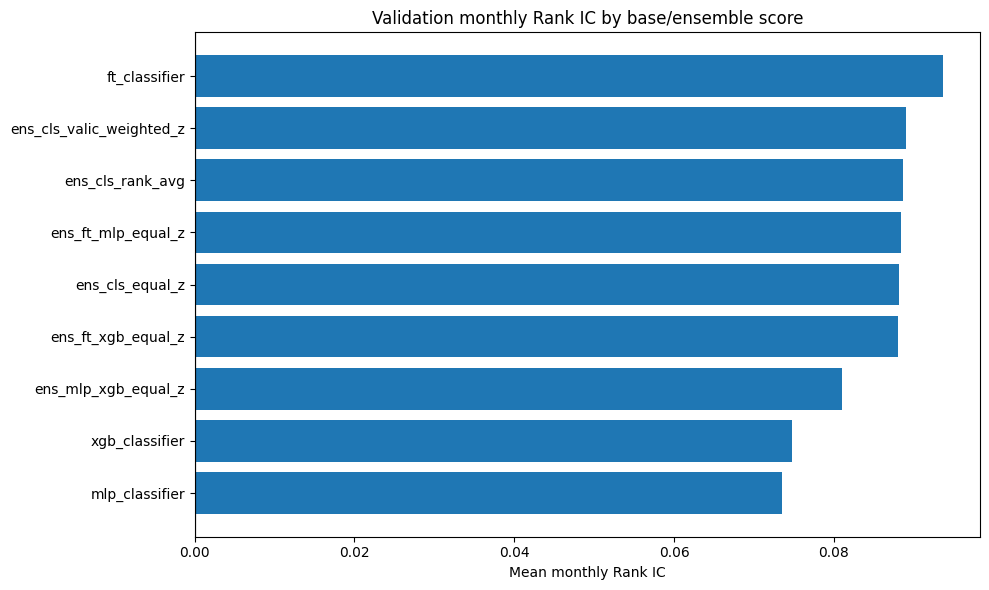

In [14]:
# Cell 14: Plot validation Rank IC by score

plot_data = (
    validation_rank_ic.loc[validation_rank_ic["score_label"].isin(candidate_score_labels)]
    .sort_values("mean_rank_ic", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_data["score_label"], plot_data["mean_rank_ic"])
ax.axvline(0, linewidth=0.8, color="black")
ax.set_title("Validation monthly Rank IC by base/ensemble score")
ax.set_xlabel("Mean monthly Rank IC")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ensemble_validation_rank_ic_by_score.png", dpi=160, bbox_inches="tight")
plt.show()


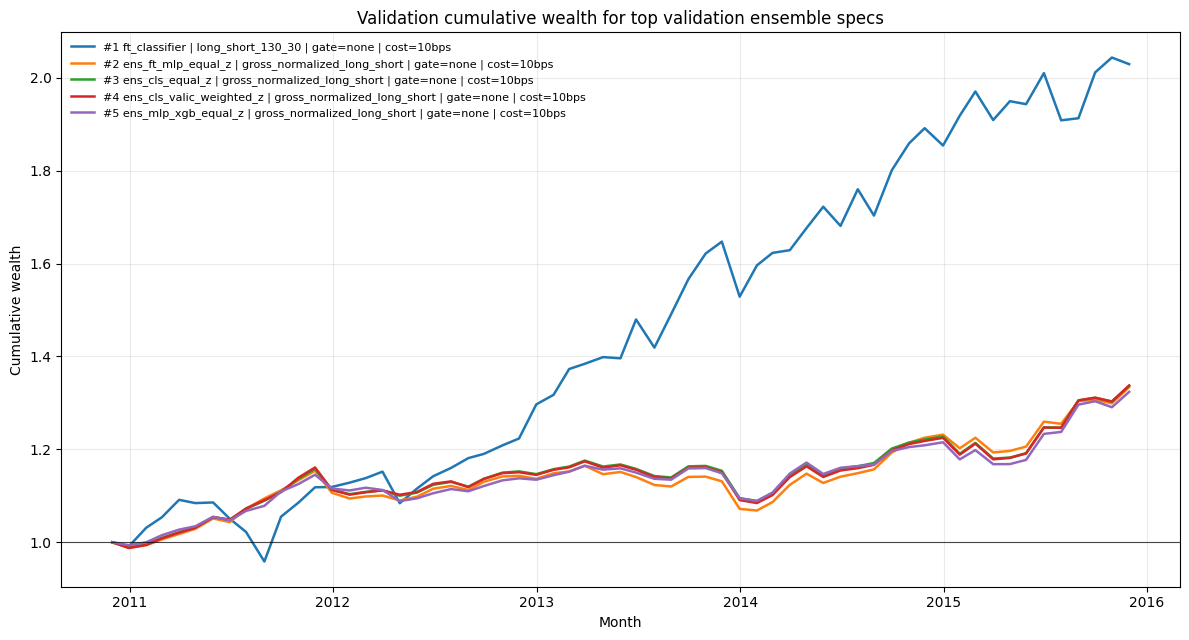

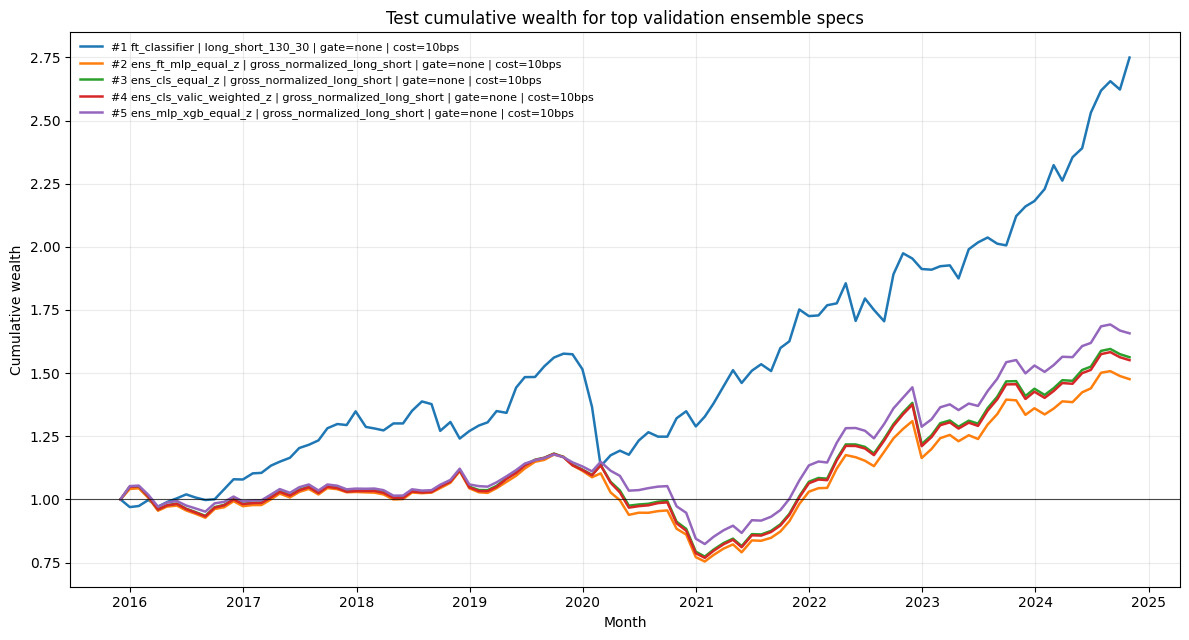

In [15]:
# Cell 15: Plot cumulative wealth for top validation-selected specs

def spec_filter(monthly: pd.DataFrame, spec: pd.Series, split: str) -> pd.Series:
    return (
        monthly["split"].eq(split)
        & monthly["score_label"].eq(spec["score_label"])
        & monthly["rule"].eq(spec["rule"])
        & np.isclose(monthly["q"].astype(float), float(spec["q"]))
        & monthly["sign_gate"].eq(bool(spec["sign_gate"]))
        & monthly["threshold_gate"].eq(bool(spec["threshold_gate"]))
        & np.isclose(monthly["zero_threshold"].astype(float), float(spec["zero_threshold"]))
        & np.isclose(monthly["one_way_cost_bps"].astype(float), float(spec["one_way_cost_bps"]))
    )


def plot_cumulative_wealth(monthly: pd.DataFrame, specs: pd.DataFrame, split: str, path: Path) -> None:
    fig, ax = plt.subplots(figsize=(12, 6.5))

    for rank, (_, spec) in enumerate(specs.iterrows(), start=1):
        part = monthly.loc[spec_filter(monthly, spec, split)].sort_values("month")
        if part.empty:
            continue

        month_index = pd.to_datetime(part["month"].to_numpy())
        returns = pd.Series(part["net_return"].fillna(0.0).to_numpy(dtype="float64"), index=month_index)
        start_month = month_index[0] - pd.offsets.MonthBegin(1)
        wealth = pd.concat([pd.Series([1.0], index=[start_month]), (1.0 + returns).cumprod()])

        if spec["threshold_gate"]:
            gate_label = f"threshold({spec['zero_threshold']:.2f})"
        elif spec["sign_gate"]:
            gate_label = "sign"
        else:
            gate_label = "none"

        label = (
            f"#{rank} {spec['score_label']} | {spec['rule']} | "
            f"gate={gate_label} | cost={spec['one_way_cost_bps']:.0f}bps"
        )
        ax.plot(wealth.index, wealth.values, linewidth=1.8, label=label)

    ax.axhline(1.0, linewidth=0.8, color="black", alpha=0.7)
    ax.set_title(f"{split.title()} cumulative wealth for top validation ensemble specs")
    ax.set_xlabel("Month")
    ax.set_ylabel("Cumulative wealth")
    ax.legend(fontsize=8, frameon=False, loc="best")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


plot_cumulative_wealth(
    portfolio_monthly,
    top_validation_specs.head(5),
    split="validation",
    path=FIGURE_DIR / "ensemble_validation_cumulative_wealth_top_specs.png",
)

plot_cumulative_wealth(
    portfolio_monthly,
    top_validation_specs.head(5),
    split="test",
    path=FIGURE_DIR / "ensemble_test_cumulative_wealth_top_validation_specs.png",
)


,xgb_classifier,mlp_classifier,ft_classifier,ens_cls_equal_z,ens_cls_rank_avg,ens_ft_mlp_equal_z,ens_ft_xgb_equal_z,ens_mlp_xgb_equal_z,ens_cls_valic_weighted_z
xgb_classifier,1.000000,0.697229,0.580179,0.806279,0.782754,0.657150,0.846223,0.833542,0.797987
mlp_classifier,0.697229,1.000000,0.626695,0.837349,0.800529,0.863077,0.698580,0.847561,0.830385
ft_classifier,0.580179,0.626695,1.000000,0.803319,0.844596,0.842719,0.828914,0.677567,0.823105
ens_cls_equal_z,0.806279,0.837349,0.803319,1.000000,0.979705,0.944437,0.943669,0.967893,0.998887
ens_cls_rank_avg,0.782754,0.800529,0.844596,0.979705,1.000000,0.937407,0.941295,0.940465,0.981396
ens_ft_mlp_equal_z,0.657150,0.863077,0.842719,0.944437,0.937407,1.000000,0.837498,0.881213,0.949780
ens_ft_xgb_equal_z,0.846223,0.698580,0.828914,0.943669,0.941295,0.837498,1.000000,0.889458,0.948622
ens_mlp_xgb_equal_z,0.833542,0.847561,0.677567,0.967893,0.940465,0.881213,0.889458,1.000000,0.956234
ens_cls_valic_weighted_z,0.797987,0.830385,0.823105,0.998887,0.981396,0.949780,0.948622,0.956234,1.000000


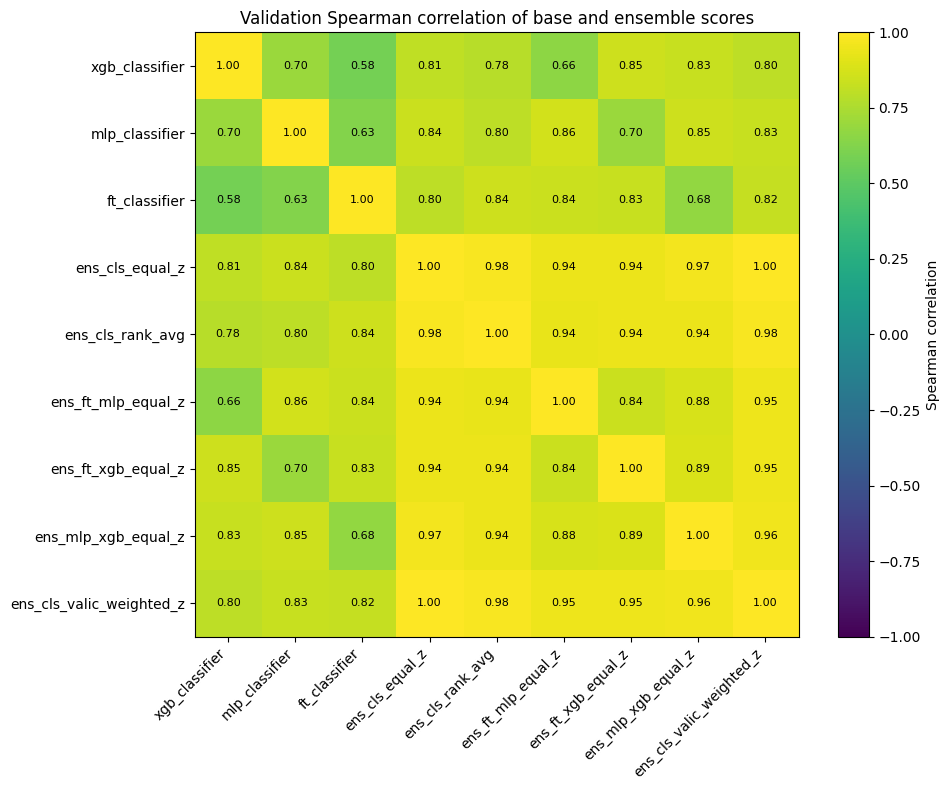

In [16]:
# Cell 16: Score correlation sanity check

corr_cols = [score_columns[s] for s in candidate_score_labels if s in score_columns]
label_lookup = {v: k for k, v in score_columns.items()}
validation_corr = (
    work.loc[work["split"].eq("validation"), corr_cols]
    .corr(method="spearman")
    .rename(index=label_lookup, columns=label_lookup)
)

validation_corr.to_csv(BACKTEST_DIR / "ensemble_validation_score_spearman_correlation.csv")

display(validation_corr)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(validation_corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(validation_corr.columns)))
ax.set_xticklabels(validation_corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(validation_corr.index)))
ax.set_yticklabels(validation_corr.index)

for i in range(validation_corr.shape[0]):
    for j in range(validation_corr.shape[1]):
        value = validation_corr.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Validation Spearman correlation of base and ensemble scores")
fig.colorbar(im, ax=ax, label="Spearman correlation")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ensemble_validation_score_correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()


In [17]:
# Cell 17: Save compact summary tables

validation_rank_ic.to_csv(BACKTEST_DIR / "ensemble_validation_score_rank_ic_ranking.csv", index=False)
selection_table.to_csv(BACKTEST_DIR / "ensemble_validation_selection_table_10bps.csv", index=False)

summary = {
    "prediction_path": str(PREDICTION_PATH.relative_to(REPO_ROOT)),
    "output_dir": str(BACKTEST_DIR.relative_to(REPO_ROOT)),
    "candidate_scores": candidate_score_labels,
    "selection_cost_bps": SELECTION_COST_BPS,
    "chosen_spec": chosen_spec,
    "ensemble_weights": ensemble_weights.to_dict(orient="records"),
}

with open(BACKTEST_DIR / "ensemble_notebook_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("Saved outputs to:")
print(BACKTEST_DIR)
print(FIGURE_DIR)


Saved outputs to:
/home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/backtests/ensemble_score_strategies
/home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/backtests/ensemble_score_strategies/figures
